In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK data
import nltk
from nltk.tokenize import sent_tokenize

# Model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Semtiment analysis
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# Import pipeline function
from transformers import pipeline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [2]:
# Download required NLTK data
nltk.download('punkt')  # Sentence tokenizer
nltk.download('words')  # English word list
nltk.download('stopwords')  # Common stopwords
nltk.download('wordnet')  # WordNet lexical database
nltk.download('punkt_tab') # Download punkt_tab resource

# Import WordNet, a lexical database used for lemmatization and semantic analysis
from nltk.corpus import wordnet
# Import a list of common English stopwords (e.g., "the", "and", "is") used for filtering out non-informative words
from nltk.corpus import stopwords
# module for stemming
from nltk.stem import PorterStemmer
 # module for tokenizing strings
from nltk.tokenize import TweetTokenizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Load and inspect the data

In [3]:
path = '/content/drive/MyDrive/files_for_colab_tutorials/NLP/final_project'
bank_df = pd.read_csv(path+'/banking_complaints_2023- complaints_banking_2023.csv')
bank_df.head()

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
0,CID76118977,1/1/2023,Checking or savings account,CASA,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief
1,CID98703933,1/1/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation
2,CID52036665,1/1/2023,Checking or savings account,CASA,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief
3,CID62581335,1/1/2023,Credit card or prepaid card,Credit Cards,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief
4,CID65731164,1/1/2023,Checking or savings account,CASA,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation


In [4]:
# Check for missing values
bank_df.isnull().sum()
# Check data types
bank_df.dtypes

,0
Complaint ID,object
Date Received,object
Banking Product,object
Department,object
Issue ID,object
Complaint Description,object
State,object
ZIP,object
Bank Response,object


In [5]:
# Convert the complaint date column to datetime (only date)

bank_df['Date Received'] = pd.to_datetime(bank_df['Date Received']).dt.date

# Get earliest and latest complaint
earliest_date = bank_df['Date Received'].min()
latest_date = bank_df['Date Received'].max()

print("Earliest Complaint Date:", earliest_date)
print("Latest Complaint Date:", latest_date)

Earliest Complaint Date: 2023-01-01
Latest Complaint Date: 2023-10-21


# Text Preprocessing


In [6]:
# Get list of stopwords
stp_wrds_eng = stopwords.words('english')

def clean_my_text(df_text_col):
  # Lower case
  clean_text = df_text_col.apply(lambda x: x.lower())
  # Remove numbers
  clean_text = clean_text.apply(lambda x: re.sub(r'\d+', '', x))
  # Remove punctuation
  clean_text = clean_text.apply(lambda x:re.sub(f'[{re.escape(string.punctuation)}]', '', x))
  # Tokenize reviews
  clean_text = clean_text.apply(lambda x: nltk.word_tokenize(x))
  # Remove stopwords
  clean_text = clean_text.apply(lambda x: [word for word in x if word not in stp_wrds_eng])
  # Lemmatize
  lemmatizer = nltk.stem.WordNetLemmatizer()
  clean_text = clean_text.apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
  return clean_text



In [7]:
clean_text = clean_my_text(bank_df['Complaint Description'])

bank_df['clean_text'] = clean_text
bank_df.head()


,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response,clean_text
0,CID76118977,2023-01-01,Checking or savings account,CASA,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief,"[xxxxxx, opened, safe, balance, account, onlin..."
1,CID98703933,2023-01-01,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation,"[item, bank, abc, credit, report, belong, must..."
2,CID52036665,2023-01-01,Checking or savings account,CASA,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief,"[xxxxxx, found, account, frozen, apparent, rea..."
3,CID62581335,2023-01-01,Credit card or prepaid card,Credit Cards,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief,"[ive, credit, card, year, bank, abc, xxxxxxxx,..."
4,CID65731164,2023-01-01,Checking or savings account,CASA,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation,"[issue, way, bank, abc, account, linking, bill..."


## Text Feature Engineering

In [8]:
# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)
# Convert the cleaned text into a TF-IDF matrix
X_tfidf = tfidf.fit_transform(bank_df['clean_text'].apply(lambda x: ' '.join(x)))


## Complaint Classification

Naive Bayes Performance:
Accuracy: 0.68496079828938
                precision    recall  f1-score   support

          CASA       0.60      0.86      0.71       350
  Credit Cards       0.61      0.76      0.68       305
Credit Reports       0.73      0.67      0.70       218
         Loans       0.84      0.66      0.74       210
      Mortgage       0.93      0.75      0.83       190
        Others       0.00      0.00      0.00        48
    Remittance       1.00      0.01      0.02        82

      accuracy                           0.68      1403
     macro avg       0.67      0.53      0.52      1403
  weighted avg       0.70      0.68      0.66      1403



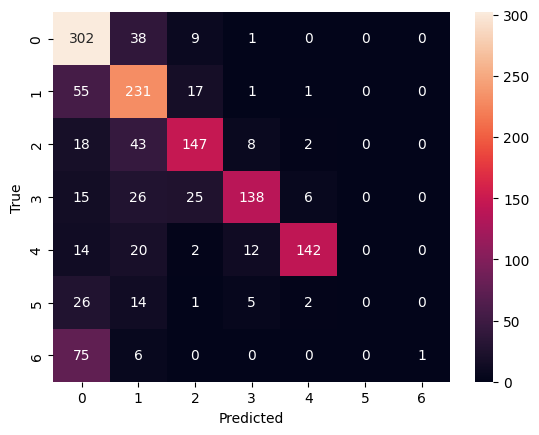

Logistic Regression Performance:
Accuracy: 0.7498218104062723
                precision    recall  f1-score   support

          CASA       0.68      0.80      0.73       350
  Credit Cards       0.73      0.77      0.75       305
Credit Reports       0.76      0.75      0.76       218
         Loans       0.77      0.80      0.78       210
      Mortgage       0.92      0.88      0.90       190
        Others       1.00      0.15      0.25        48
    Remittance       0.65      0.40      0.50        82

      accuracy                           0.75      1403
     macro avg       0.79      0.65      0.67      1403
  weighted avg       0.76      0.75      0.74      1403



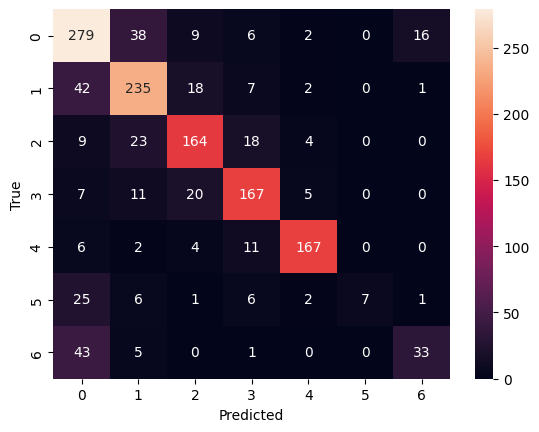

In [9]:
from sklearn.metrics import confusion_matrix

# Define the target variable (department)
y = bank_df['Department']
# Build a classification model with input = x_tdidf and output = y
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Naive Bayes Model
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_test)

print("Naive Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))

# confusion matrix
cm = confusion_matrix(y_test, nb_preds)
# plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Logistic Regression Model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, logreg_preds))
print(classification_report(y_test, logreg_preds))

# plot confusion matrix
cm = confusion_matrix(y_test, logreg_preds)
# plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


##Apply VADER
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based, open-source sentiment analysis tool specifically designed for social media text and online reviews. It efficiently classifies text as positive, negative, or neutral based on word intensity, punctuation (e.g., "!!!"), capitalization, and intensifiers (e.g., "very").

In [10]:
# Apply VADER

sia = SentimentIntensityAnalyzer()
# Predict vader score and apply to the data
bank_df['vader_scores'] = bank_df['Complaint Description'].apply(
    lambda x: sia.polarity_scores(str(x))
)

# Extract VADER compound score
bank_df['vader_compound'] = bank_df['vader_scores'].apply(
    lambda x: x['compound']
)
# Convert score to sentiment
def vader_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

bank_df['vader_sentiment'] = bank_df['vader_compound'].apply(vader_label)



In [11]:
bank_df.head()

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response,clean_text,vader_scores,vader_compound,vader_sentiment
0,CID76118977,2023-01-01,Checking or savings account,CASA,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief,"[xxxxxx, opened, safe, balance, account, onlin...","{'neg': 0.081, 'neu': 0.893, 'pos': 0.026, 'co...",-0.9488,negative
1,CID98703933,2023-01-01,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation,"[item, bank, abc, credit, report, belong, must...","{'neg': 0.095, 'neu': 0.817, 'pos': 0.089, 'co...",-0.1207,negative
2,CID52036665,2023-01-01,Checking or savings account,CASA,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief,"[xxxxxx, found, account, frozen, apparent, rea...","{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.5267,negative
3,CID62581335,2023-01-01,Credit card or prepaid card,Credit Cards,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief,"[ive, credit, card, year, bank, abc, xxxxxxxx,...","{'neg': 0.089, 'neu': 0.848, 'pos': 0.064, 'co...",-0.8796,negative
4,CID65731164,2023-01-01,Checking or savings account,CASA,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation,"[issue, way, bank, abc, account, linking, bill...","{'neg': 0.053, 'neu': 0.85, 'pos': 0.097, 'com...",0.9357,positive


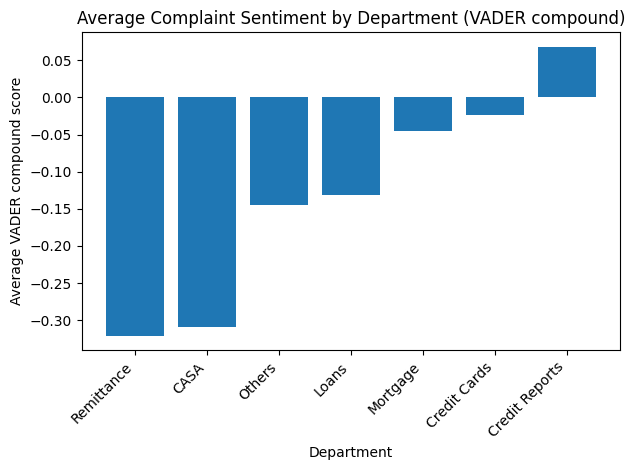

,mean,median,n
Department,,,
Remittance,-0.321121,-0.60780,422
CASA,-0.308735,-0.51160,1655
Others,-0.145397,-0.29600,257
Loans,-0.131610,-0.22630,1111
Mortgage,-0.045491,-0.06365,848
Credit Cards,-0.023929,0.00000,1609
Credit Reports,0.068072,0.15310,1109


In [12]:
# Average VADER compound score by department

dept_summary = (
    bank_df.groupby('Department')['vader_compound']
      .agg(mean='mean', median='median', n='count')
      .sort_values('mean')
)

plt.figure()
plt.bar(dept_summary.index, dept_summary['mean'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Department')
plt.ylabel('Average VADER compound score')
plt.title('Average Complaint Sentiment by Department (VADER compound)')
plt.tight_layout()
plt.show()

# (Optional) print the table you’re plotting (nice for the report)
dept_summary


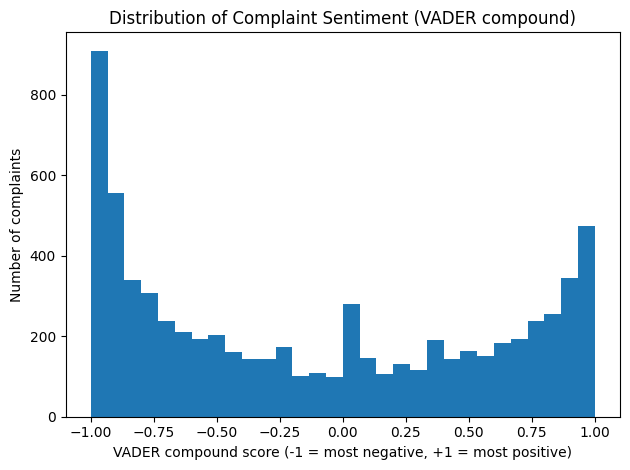

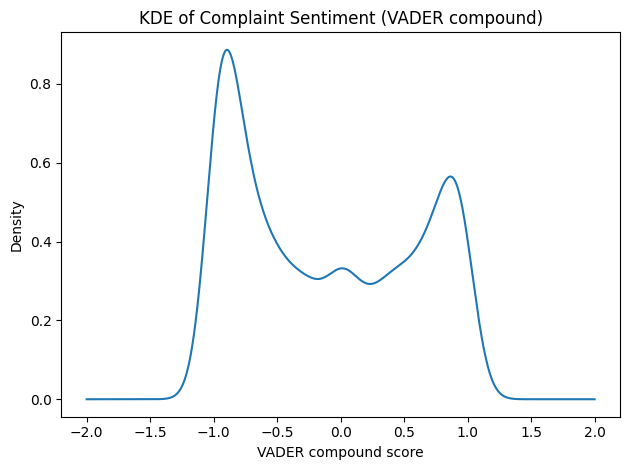

In [13]:

# Optional KDE (no seaborn) — smooth density curve
plt.figure()
bank_df['vader_compound'].plot(kind='kde')
plt.xlabel('VADER compound score')
plt.ylabel('Density')
plt.title('KDE of Complaint Sentiment (VADER compound)')
plt.tight_layout()
plt.show()


## Apply BERT and discuss model performance

In [14]:
# Load sentimet analysis with BERT
classifier = pipeline(
    "sentiment-analysis",
    model = "distilbert-base-uncased-finetuned-sst-2-english"
    , device=0)
# Run analysis and collect results

labels = []
scores = []

for complaint in bank_df['Complaint Description']:
    # Return the prediction dictionary using [0]
    # Add truncation=True to handle sequences longer than the model's max length
    out = classifier(complaint, truncation=True)[0]
    labels.append(out['label'])
    scores.append(out['score'])

bank_df['bert_sentiment'] = labels
bank_df['bert_confidence'] = scores


# Run sentiment analysis and collect results for bike_df
labels = []
scores = []

# Change sentiment to 'neutral' if confidence is <0.6
def map_to_three_classes(label, score, threshold=0.6):
    if score < threshold:
        return "NEUTRAL"
    return label

bank_df['sentiment_3class'] = [
    map_to_three_classes(l, s)
    for l, s in zip(bank_df['bert_sentiment'], bank_df['bert_confidence'])
]

bank_df

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response,clean_text,vader_scores,vader_compound,vader_sentiment,bert_sentiment,bert_confidence,sentiment_3class
0,CID76118977,2023-01-01,Checking or savings account,CASA,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief,"[xxxxxx, opened, safe, balance, account, onlin...","{'neg': 0.081, 'neu': 0.893, 'pos': 0.026, 'co...",-0.9488,negative,NEGATIVE,0.999429,NEGATIVE
1,CID98703933,2023-01-01,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation,"[item, bank, abc, credit, report, belong, must...","{'neg': 0.095, 'neu': 0.817, 'pos': 0.089, 'co...",-0.1207,negative,NEGATIVE,0.999340,NEGATIVE
2,CID52036665,2023-01-01,Checking or savings account,CASA,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief,"[xxxxxx, found, account, frozen, apparent, rea...","{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.5267,negative,NEGATIVE,0.999526,NEGATIVE
3,CID62581335,2023-01-01,Credit card or prepaid card,Credit Cards,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief,"[ive, credit, card, year, bank, abc, xxxxxxxx,...","{'neg': 0.089, 'neu': 0.848, 'pos': 0.064, 'co...",-0.8796,negative,NEGATIVE,0.998561,NEGATIVE
4,CID65731164,2023-01-01,Checking or savings account,CASA,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation,"[issue, way, bank, abc, account, linking, bill...","{'neg': 0.053, 'neu': 0.85, 'pos': 0.097, 'com...",0.9357,positive,NEGATIVE,0.999218,NEGATIVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7006,CID63720677,2023-07-06,Mortgage,Mortgage,I_2806126,I spoke with XXXX XXXX of Capital One in XX/XX...,New York,114XX,Closed with explanation,"[spoke, xxxx, xxxx, capital, one, xxxxxxxx, ex...","{'neg': 0.037, 'neu': 0.917, 'pos': 0.046, 'co...",0.8782,positive,NEGATIVE,0.997682,NEGATIVE
7007,CID93313606,2023-07-06,Mortgage,Mortgage,I_4197360,1. PNC customer service & the letter I receive...,Ohio,430XX,Closed with explanation,"[pnc, customer, service, letter, receive, cont...","{'neg': 0.055, 'neu': 0.912, 'pos': 0.033, 'co...",-0.9327,negative,NEGATIVE,0.989654,NEGATIVE
7008,CID13952171,2023-07-06,Mortgage,Mortgage,I_4197360,We went to refinance with another company due ...,Maryland,212XX,Closed with explanation,"[went, refinance, another, company, due, xxxx,...","{'neg': 0.057, 'neu': 0.871, 'pos': 0.072, 'co...",-0.1359,negative,NEGATIVE,0.994003,NEGATIVE
7009,CID32570168,2023-07-06,Credit reporting,Credit Reports,I_9082488,After XXXX letters mailed to Transunion via ce...,Idaho,836XX,Closed with explanation,"[xxxx, letter, mailed, transunion, via, certif...","{'neg': 0.0, 'neu': 0.95, 'pos': 0.05, 'compou...",0.2732,positive,NEGATIVE,0.998626,NEGATIVE


# Summary Report:
### Project overview:
The complaints dataset was loaded into Python, data types were checked and corrected, and the overall date range was identified to confirm coverage of the analysis period. Complaint descriptions were preprocessed using a standardized NLP pipeline (lowercasing, removing numbers and punctuation, stopword removal, and lemmatization). Cleaned complaint text was then transformed into a TF-IDF feture matrix for downstream modeling.

### Department classification
To automate triaging, the “Department” field was used as the target variable in a multi-class text classification task. Two baseline models were trained and evaluated: Multinomial Naive Bayes and Logistic Regression. Naive Bayes achieved ~0.685 accuracy, but performed poorly on minority departments (e.g., Others and Remittance), indicating sensitivity to class imbalance. Logistic Regression improved overall performance to ~0.750 accuracy and increased macro-level performance, showing stronger and more consistent discrimination across the major departments (e.g., Mortgage, Loans, Credit Reports), though small classes remained more difficult.

### Sentiment analysis and insights (VADER).
SentimentIntensityAnalyzer (VADER) was applied to complaint text to compute positive/neutral/negative proportions and a compound score between −1 and +1, representing overall sentiment intensity. Two plots were generated to support business interpretation:

1. Average VADER compound score by department, highlighting which product areas are associated with the most negative customer sentiment and therefore may require targeted process or product improvements.
2. Distribution of compound scores, showing the overall severity spread of complaints and enabling threshold-based escalation (e.g., very negative scores as “critical” complaints).

### Transformer-based sentiment analysis (BERT)
In addition to VADER, a pre-trained DistilBERT sentiment model (fine-tuned on SST-2) was applied to the complaint descriptions. BERT produced highly confident sentiment predictions, with the majority of complaints classified as NEGATIVE with confidence scores close to 1.0. This outcome is consistent with the nature of the dataset, which consists primarily of grievances rather than neutral customer feedback.
To extend BERT’s binary output to a three-class setting, a confidence-based heuristic was applied: predictions with confidence below a predefined threshold were labeled as NEUTRAL. This allowed limited alignment with the three-class sentiment framing used elsewhere in the analysis.

### Comparison and interpretation of VADER vs BERT
While both approaches identify widespread negative sentiment, they capture different aspects of customer dissatisfaction:
VADER provides a graded measure of sentiment intensity, distinguishing mild dissatisfaction from extreme frustration.
BERT produces highly confident categorical judgments, often labeling complaints as negative even when VADER indicates positive or neutral sentiment at the lexical level.
Observed disagreements (e.g., VADER-positive but BERT-negative cases) typically correspond to complaints that are factually resolved but still embedded in a grievance context. This highlights that BERT captures contextual complaint framing, whereas VADER emphasizes lexical sentiment inten

### Results interpretation: Combining both sentiment approaches offers complementary value:
VADER compound scores can be used to prioritize complaints by severity and urgency.
BERT sentiment labels can serve as a robust signal for detecting grievance framing at scale.
Together with department classification, these methods enable automated routing, severity-based prioritization, and department-level monitoring of customer dissatisfaction.

### Business use
This project demonstrates a complete NLP-driven grievance analysis pipeline, integrating text preprocessing, TF-IDF–based classification, lexicon-based sentiment analysis, and transformer-based sentiment inference. The combined use of VADER and BERT provides both interpretable severity scores and robust contextual sentiment detection, enabling actionable insights to improve complaint handling efficiency, customer experience, and regulatory risk monitoring.